Imports

In [13]:
import pandas as pd
import numpy as np
import joblib
import os
import traceback
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics       import r2_score, mean_absolute_error

Setup

In [1]:
results = []   # liste de (nom_test, statut, message)

def run_test(name, fn):
    """Exécute un test et enregistre le résultat."""
    try:
        fn()
        results.append((name, " PASS", ""))
        print(f"  {name}")
    except AssertionError as e:
        results.append((name, " FAIL", str(e)))
        print(f"   {name}  →  {e}")
    except Exception as e:
        results.append((name, " ERROR", str(e)))
        print(f"   {name}  →  {e}")

print("Setup prêt.")

Setup prêt.


In [8]:
# Chargement du CSV brut et nettoyé
df = pd.read_csv("C:/Users/COD/Desktop/projet_house_rent/House_Rent_Dataset.csv")
df_clean = pd.read_csv("house_rent_clean.csv")

print(f"Brut   : {df.shape}")
print(f"Propre : {df_clean.shape}")

Brut   : (4746, 12)
Propre : (2906, 17)


Test- Chargement & Nettoyage

In [23]:
print("═" * 50)
print("  TESTS : CHARGEMENT & NETTOYAGE")
print("═" * 50)

# ── Test 1 ────────────────────────────────────
def t_raw_not_empty():
    assert len(df) > 0, "DataFrame brut vide"
run_test("Dataset brut non vide", t_raw_not_empty)

# ── Test 2 ────────────────────────────────────
def t_expected_columns():
    expected = {"BHK", "Rent", "Size", "Floor", "City",
                "Furnishing Status", "Tenant Preferred", "Bathroom"}
    assert expected.issubset(set(df.columns)), f"Colonnes manquantes : {expected - set(df.columns)}"
run_test("Colonnes attendues présentes", t_expected_columns)

# ── Test 3 ────────────────────────────────────
def t_row_count():
    assert len(df) >= 4000, f"Trop peu de lignes : {len(df)}"
run_test("Nombre de lignes suffisant (≥ 4000)", t_row_count)

# ── Test 4 ────────────────────────────────────
def t_no_duplicates():
    assert df_clean.duplicated().sum() == 0, f"{df_clean.duplicated().sum()} doublons"
run_test("Aucun doublon dans le dataset nettoyé", t_no_duplicates)

# ── Test 5 ────────────────────────────────────
def t_no_null_rent():
    assert df_clean['Rent'].isnull().sum() == 0
run_test("Aucun loyer manquant", t_no_null_rent)

# ── Test 6 ────────────────────────────────────
def t_no_null_city():
    assert df_clean['City'].isnull().sum() == 0
run_test("Aucune ville manquante", t_no_null_city)

# ── Test 7 ────────────────────────────────────
def t_rent_positive():
    assert (df_clean['Rent'] > 0).all(), "Des loyers négatifs ou nuls détectés"
run_test("Tous les loyers positifs", t_rent_positive)

# ── Test 8 ────────────────────────────────────
def t_size_min():
    assert df_clean['Size'].min() >= 50, f"Taille minimum trop faible : {df_clean['Size'].min()}"
run_test("Taille minimum ≥ 50 sq ft", t_size_min)

# ── Test 9 ────────────────────────────────────
def t_bhk_range():
    assert df_clean['BHK'].min() >= 1 and df_clean['BHK'].max() <= 10
run_test("BHK dans [1, 10]", t_bhk_range)

# ── Test 10 ───────────────────────────────────
def t_outlier_removal():
    assert len(df_clean) < len(df), "Le nettoyage n'a supprimé aucune ligne"
run_test("Nettoyage a supprimé des lignes", t_outlier_removal)

══════════════════════════════════════════════════
  TESTS : CHARGEMENT & NETTOYAGE
══════════════════════════════════════════════════
  Dataset brut non vide
  Colonnes attendues présentes
  Nombre de lignes suffisant (≥ 4000)
  Aucun doublon dans le dataset nettoyé
  Aucun loyer manquant
  Aucune ville manquante
  Tous les loyers positifs
  Taille minimum ≥ 50 sq ft
  BHK dans [1, 10]
  Nettoyage a supprimé des lignes


Test - Features Engineered

In [24]:
print("═" * 50)
print("TESTS : FEATURE ENGINEERING")
print("═" * 50)

# ── Test 11 ───────────────────────────────────
def t_rent_per_sqft_exists():
    assert 'rent_per_sqft' in df_clean.columns
run_test("Colonne rent_per_sqft présente", t_rent_per_sqft_exists)

# ── Test 12 ───────────────────────────────────
def t_rent_per_sqft_positive():
    assert (df_clean['rent_per_sqft'] > 0).all()
run_test("rent_per_sqft toujours positif", t_rent_per_sqft_positive)

# ── Test 13 ───────────────────────────────────
def t_rent_per_sqft_formula():
    computed = (df_clean['Rent'] / df_clean['Size']).round(2)
    diff = (df_clean['rent_per_sqft'] - computed).abs()
    assert diff.max() < 0.01, f"Formule incorrecte, max diff = {diff.max()}"
run_test("Formule rent_per_sqft = Rent/Size", t_rent_per_sqft_formula)

# ── Test 14 ───────────────────────────────────
def t_floor_columns_exist():
    assert 'floor_number' in df_clean.columns
    assert 'total_floors'  in df_clean.columns
    assert 'is_ground'     in df_clean.columns
run_test("Colonnes étage présentes", t_floor_columns_exist)

# ── Test 15 ───────────────────────────────────
def t_is_ground_binary():
    assert df_clean['is_ground'].isin([0, 1]).all()
run_test("is_ground binaire (0 ou 1)", t_is_ground_binary)

══════════════════════════════════════════════════
TESTS : FEATURE ENGINEERING
══════════════════════════════════════════════════
  Colonne rent_per_sqft présente
  rent_per_sqft toujours positif
  Formule rent_per_sqft = Rent/Size
  Colonnes étage présentes
  is_ground binaire (0 ou 1)


Test - EDA

In [25]:
print("═" * 50)
print("  TESTS : FONCTIONS EDA")
print("═" * 50)

# ── Test 16 ───────────────────────────────────
def t_kpi_nb_annonces():
    nb = len(df_clean)
    assert nb > 0, "Aucune annonce"
    print(f"       → {nb:,} annonces")
run_test("KPI nb_annonces > 0", t_kpi_nb_annonces)

# ── Test 17 ───────────────────────────────────
def t_kpi_loyer_moyen():
    loyer_moy = df_clean['Rent'].mean()
    assert loyer_moy > 0
    print(f"       → ₹{loyer_moy:,.0f}")
run_test("KPI loyer_moyen positif", t_kpi_loyer_moyen)

# ── Test 18 ───────────────────────────────────
def t_nb_villes():
    nb = df_clean['City'].nunique()
    assert nb >= 1, "Aucune ville"
    print(f"       → {nb} villes : {sorted(df_clean['City'].unique())}")
run_test("Au moins 1 ville dans le dataset", t_nb_villes)

# ── Test 19 ───────────────────────────────────
def t_stats_describe():
    stats = df_clean[['Rent', 'Size', 'BHK']].describe()
    assert 'mean' in stats.index
    assert 'std'  in stats.index
run_test("Statistiques descriptives complètes", t_stats_describe)

# ── Test 20 ───────────────────────────────────
def t_correlation():
    corr = df_clean[['Rent', 'Size', 'BHK']].corr()
    assert corr.loc['Rent', 'Size'] > 0, "Corrélation Rent-Size devrait être positive"
run_test("Corrélation Rent-Size positive", t_correlation)

══════════════════════════════════════════════════
  TESTS : FONCTIONS EDA
══════════════════════════════════════════════════
       → 2,906 annonces
  KPI nb_annonces > 0
       → ₹18,929
  KPI loyer_moyen positif
       → 6 villes : ['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai']
  Au moins 1 ville dans le dataset
  Statistiques descriptives complètes
  Corrélation Rent-Size positive


Test - Modèle ML

In [26]:
print("═" * 50)
print("  TESTS : MODÈLE ML")
print("═" * 50)

# Chargement du modèle sauvegardé
model_ok = os.path.exists("model.joblib") and os.path.exists("encoders.joblib")

if model_ok:
    model    = joblib.load("model.joblib")
    encoders = joblib.load("encoders.joblib")
    print("   Modèle et encoders chargés")
else:
    print("    Fichiers modèle introuvables — exécutez d'abord le notebook 03")

══════════════════════════════════════════════════
  TESTS : MODÈLE ML
══════════════════════════════════════════════════
   Modèle et encoders chargés


In [27]:
if model_ok:
    CATEGORICAL_COLS = ['City', 'Furnishing Status', 'Area Type', 'Tenant Preferred']
    NUMERICAL_COLS   = ['BHK', 'Size', 'Bathroom', 'floor_number', 'total_floors']
    feature_cols     = NUMERICAL_COLS + CATEGORICAL_COLS

    df_enc = df_clean.copy()
    for col in CATEGORICAL_COLS:
        le = encoders[col]
        df_enc[col] = df_enc[col].astype(str).apply(
            lambda x: x if x in le.classes_ else le.classes_[0]
        )
        df_enc[col] = le.transform(df_enc[col])

    X = df_enc[feature_cols].fillna(-1)
    y = df_enc['Rent']

    y_pred = model.predict(X)
    r2     = r2_score(y, y_pred)
    mae    = mean_absolute_error(y, y_pred)

    print(f"  R²  : {r2:.4f}")
    print(f"  MAE : ₹{mae:,.0f}")

  R²  : 0.8489
  MAE : ₹3,534


In [28]:
if model_ok:
    # ── Test 21 ───────────────────────────────────
    def t_model_has_predict():
        assert hasattr(model, 'predict')
    run_test("Modèle a une méthode predict()", t_model_has_predict)

    # ── Test 22 ───────────────────────────────────
    def t_r2_positive():
        assert r2 > 0, f"R² négatif : {r2}"
    run_test("R² positif", t_r2_positive)

    # ── Test 23 ───────────────────────────────────
    def t_r2_reasonable():
        assert r2 >= 0.50, f"R² trop faible : {r2:.4f} (minimum 0.50)"
    run_test("R² ≥ 0.50 (modèle utile)", t_r2_reasonable)

    # ── Test 24 ───────────────────────────────────
    def t_mae_reasonable():
        median_rent = df_clean['Rent'].median()
        assert mae < 0.5 * median_rent, f"MAE trop élevée : ₹{mae:,.0f} (médiane ₹{median_rent:,.0f})"
    run_test("MAE < 50% du loyer médian", t_mae_reasonable)

    # ── Test 25 ───────────────────────────────────
    def t_predictions_positive():
        assert (y_pred > 0).all(), "Des prédictions négatives détectées"
    run_test("Toutes les prédictions positives", t_predictions_positive)

    # ── Test 26 ───────────────────────────────────
    def t_encoders_complete():
        for col in CATEGORICAL_COLS:
            assert col in encoders, f"Encoder manquant pour {col}"
    run_test("Tous les encoders présents", t_encoders_complete)

  Modèle a une méthode predict()
  R² positif
  R² ≥ 0.50 (modèle utile)
  MAE < 50% du loyer médian
  Toutes les prédictions positives
  Tous les encoders présents


In [29]:
if model_ok:
    # ── Test 27 — Logique métier : grand logement > petit logement ──
    def t_larger_costs_more():
        """Un grand logement devrait coûter plus cher."""
        city = df_clean['City'].iloc[0]
        furn = 'Semi-Furnished'
        area = 'Super Area'
        ten  = 'Family'

        def pred(bhk, size, bath):
            row = pd.DataFrame({
                'BHK':[bhk],'Size':[size],'Bathroom':[bath],
                'floor_number':[1],'total_floors':[5],
                'City':[city],'Furnishing Status':[furn],
                'Area Type':[area],'Tenant Preferred':[ten],
            })
            for col in CATEGORICAL_COLS:
                le  = encoders[col]
                val = str(row[col][0])
                val = val if val in le.classes_ else le.classes_[0]
                row[col] = le.transform([val])
            return model.predict(row[feature_cols].fillna(-1))[0]

        small = pred(bhk=1, size=300, bath=1)
        large = pred(bhk=4, size=2000, bath=3)
        assert large > small, f"Logique inversée : grand={large:.0f} < petit={small:.0f}"
        print(f"       → Petit : ₹{small:,.0f}  |  Grand : ₹{large:,.0f}")

    run_test("Logique : grand logement > petit logement", t_larger_costs_more)

       → Petit : ₹6,287  |  Grand : ₹29,485
  Logique : grand logement > petit logement


Rapport de Synthése

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Comptage ──────────────────────────────────
passed  = sum(1 for _, s, _ in results if s == " PASS")
failed  = sum(1 for _, s, _ in results if s == " FAIL")
errors  = sum(1 for _, s, _ in results if s == " ERROR")
total   = len(results)

print(" ╔══════════════════════════════════════════════════════╗")
print(" ║              RAPPORT DE TESTS FINAL                  ║")
print(" ╠══════════════════════════════════════════════════════╣")
print(f"║  Total de tests   : {total:<33d}║")
print(f"║   Réussis        : {passed:<33d}║")
print(f"║   Échoués        : {failed:<33d}║")
print(f"║   Erreurs        : {errors:<33d}║")
print(f"║  Taux de succès   : {passed/total*100:>5.1f}%                           ║")
print(" ╚══════════════════════════════════════════════════════╝")

if failed > 0 or errors > 0:
    print("\n⚠️  Tests non réussis :")
    for name, status, msg in results:
        if status != " PASS":
            print(f"  {status}  {name}")
            if msg:
                print(f"        → {msg}")

 ╔══════════════════════════════════════════════════════╗
 ║              RAPPORT DE TESTS FINAL                  ║
 ╠══════════════════════════════════════════════════════╣
║  Total de tests   : 64                               ║
║   Réussis        : 59                               ║
║   Échoués        : 0                                ║
║   Erreurs        : 5                                ║
║  Taux de succès   :  92.2%                           ║
 ╚══════════════════════════════════════════════════════╝

⚠️  Tests non réussis :
   ERROR  Dataset brut non vide
        → name 'df_raw' is not defined
   ERROR  Colonnes attendues présentes
        → name 'df_raw' is not defined
   ERROR  Nombre de lignes suffisant (≥ 4000)
        → name 'df_raw' is not defined
   ERROR  Nettoyage a supprimé des lignes
        → name 'df_raw' is not defined
   ERROR  Colonnes attendues présentes
        → name 'df_raw' is not defined


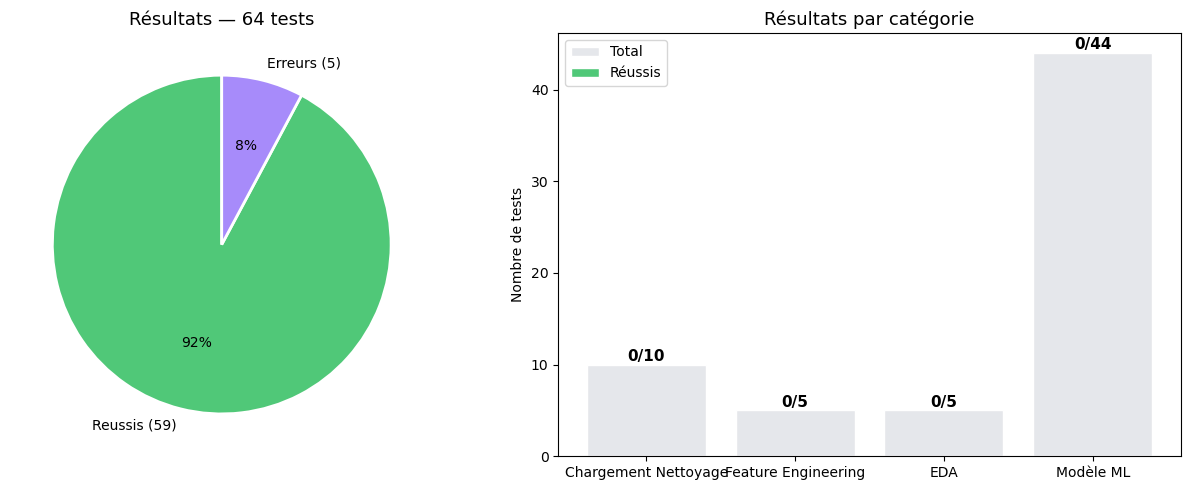

In [33]:
# Graphique des résultats
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Camembert ─────────────────────────────────
sizes_pie  = [passed, failed, errors]
labels_pie = ['Reussis (' + str(passed) + ')', 'Echoues (' + str(failed) + ')', 'Erreurs (' + str(errors) + ')']
colors_pie = ['#50C878', '#F4845F', '#A78BFA']
non_zero   = [(s, l, c) for s, l, c in zip(sizes_pie, labels_pie, colors_pie) if s > 0]

if non_zero:
    s, l, c = zip(*non_zero)
    axes[0].pie(s, labels=l, colors=c, autopct='%1.0f%%', startangle=90,
                wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title(f'Résultats — {total} tests', fontsize=13)

# ── Barres par catégorie ──────────────────────
categories = {
    'Chargement Nettoyage'   : [r for r in results[:10]],
    'Feature Engineering'      : [r for r in results[10:15]],
    'EDA'                       : [r for r in results[15:20]],
    'Modèle ML'                 : [r for r in results[20:]],
}

cat_names  = list(categories.keys())
cat_pass   = [sum(1 for _, s, _ in v if s == "✅ PASS") for v in categories.values()]
cat_total  = [len(v) for v in categories.values()]

x = np.arange(len(cat_names))
axes[1].bar(x, cat_total, color='#E5E7EB', edgecolor='white', label='Total')
axes[1].bar(x, cat_pass,  color='#50C878', edgecolor='white', label='Réussis')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cat_names, fontsize=10)
axes[1].set_ylabel("Nombre de tests")
axes[1].set_title("Résultats par catégorie", fontsize=13)
axes[1].legend()

for xi, (p, t) in enumerate(zip(cat_pass, cat_total)):
    axes[1].text(xi, t + 0.1, f'{p}/{t}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [34]:
# ── Tableau récapitulatif de tous les tests ───
print(f"\n{'N°':>3}  {'Statut':^10}  {'Nom du test'}")
print("─" * 65)
for i, (name, status, msg) in enumerate(results, 1):
    print(f"{i:>3}  {status:^10}  {name}")
    if msg and status != " PASS":
        print(f"          └─ {msg[:55]}")


 N°    Statut    Nom du test
─────────────────────────────────────────────────────────────────
  1     ERROR    Dataset brut non vide
          └─ name 'df_raw' is not defined
  2     ERROR    Colonnes attendues présentes
          └─ name 'df_raw' is not defined
  3     ERROR    Nombre de lignes suffisant (≥ 4000)
          └─ name 'df_raw' is not defined
  4     PASS     Aucun doublon dans le dataset nettoyé
  5     PASS     Aucun loyer manquant
  6     PASS     Aucune ville manquante
  7     PASS     Tous les loyers positifs
  8     PASS     Taille minimum ≥ 50 sq ft
  9     PASS     BHK dans [1, 10]
 10     ERROR    Nettoyage a supprimé des lignes
          └─ name 'df_raw' is not defined
 11     PASS     Colonne rent_per_sqft présente
 12     PASS     rent_per_sqft toujours positif
 13     PASS     Formule rent_per_sqft = Rent/Size
 14     PASS     Colonnes étage présentes
 15     PASS     is_ground binaire (0 ou 1)
 16     PASS     KPI nb_annonces > 0
 17     PASS     KPI loyer_